In [ ]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

## Data Cleaning

In [ ]:
path = Path(r"source_data\crime.csv")
path

WindowsPath('source_data/crime.csv')

In [7]:
df = pd.read_csv(path, encoding='cp1252')
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type_id,criminal-mischief-other,criminal-mischief-other
offense_category_id,public-disorder,public-disorder
first_occurrence_date,2/10/2022 2:50:00 AM,7/7/2021 9:02:00 PM
last_occurrence_date,NaN,NaN
reported_date,2/10/2022 3:16:00 AM,7/8/2021 12:55:00 AM
incident_address,1107 N SANTA FE DR,815 16TH ST


In [11]:
df.dtypes

incident_id                 int64
offense_id                  int64
offense_code                int64
offense_code_extension      int64
offense_type_id            object
offense_category_id        object
first_occurrence_date      object
last_occurrence_date       object
reported_date              object
incident_address           object
geo_x                     float64
geo_y                     float64
geo_lon                   float64
geo_lat                   float64
district_id                object
precinct_id                 int64
neighborhood_id            object
is_crime                    int64
is_traffic                  int64
victim_count                int64
dtype: object

In [16]:
df.first_occurrence_date = pd.to_datetime(df['first_occurrence_date'])
df.last_occurrence_date = pd.to_datetime(df['last_occurrence_date'])
df.reported_date = pd.to_datetime(df['reported_date'])

In [26]:
df.district_id = df.district_id.replace('U', 'unknown')
df.district_id.unique()

array(['1', '6', '4', '5', '2', '3', '7', 'unknown', nan], dtype=object)

In [32]:
df.precinct_id.unique()

array([123, 611, 111, 411, 521, 113, 623, 212, 213, 211, 523, 511, 313,
       621, 412, 612, 322, 221, 512, 121, 122, 112, 622, 522, 311, 223,
       314, 422, 222, 423, 323, 321, 759, 312, 421, 324, 999, 316, 436,
       532, 232], dtype=int64)

In [33]:
df.neighborhood_id.unique()

array(['lincoln-park', 'cbd', 'berkeley', 'barnum', 'montbello',
       'highland', 'capitol-hill', 'clayton', 'congress-park', 'whittier',
       'barnum-west', 'gateway-green-valley-ranch', 'central-park',
       'platt-park', 'north-capitol-hill', 'athmar-park', 'union-station',
       'washington-virginia-vale', 'northeast-park-hill', 'west-colfax',
       'five-points', 'westwood', 'civic-center', 'sunnyside',
       'cheesman-park', 'city-park-west', 'baker', 'east-colfax',
       'skyland', 'university-hills', 'overland', 'west-highland',
       'valverde', 'college-view-south-platte', 'jefferson-park',
       'cherry-creek', 'hale', 'harvey-park-south', 'hampden', 'rosedale',
       'globeville', 'goldsmith', 'lowry-field', 'speer',
       'elyria-swansea', 'chaffee-park', 'villa-park', 'sun-valley',
       'dia', 'cory-merrill', 'cole', 'harvey-park',
       'washington-park-west', 'washington-park', 'mar-lee', 'university',
       'bear-valley', 'hampden-south', 'belcaro', 'c

In [ ]:
df.is_crime = df.is_crime.apply(lambda x: True if x == 1 else False)
df.is_traffic = df.is_traffic.apply(lambda x: True if x == 1 else False)
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type_id,criminal-mischief-other,criminal-mischief-other
offense_category_id,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_date,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_address,1107 N SANTA FE DR,815 16TH ST


In [44]:
df.dtypes

incident_id                        int64
offense_id                         int64
offense_code                       int64
offense_code_extension             int64
offense_type_id                   object
offense_category_id               object
first_occurrence_date     datetime64[ns]
last_occurrence_date      datetime64[ns]
reported_date             datetime64[ns]
incident_address                  object
geo_x                            float64
geo_y                            float64
geo_lon                          float64
geo_lat                          float64
district_id                       object
precinct_id                       object
neighborhood_id                   object
is_crime                            bool
is_traffic                          bool
victim_count                       int64
dtype: object

In [47]:
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type_id,criminal-mischief-other,criminal-mischief-other
offense_category_id,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_date,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_address,1107 N SANTA FE DR,815 16TH ST


In [52]:
df.rename(mapper={
    'offense_type_id': 'offense_type',
    'offense_category_id': 'offense_category',
    'incident_address': 'incident_street_address',
    'geo_lon': 'incident_longitude',
    'geo_lat': 'incident_latitude',
    'neighborhood_id': 'neighborhood_name',
}, axis=1, inplace=True)
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_date,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST


## Visualizing High Level Insights

In [90]:
df.offense_category.unique()

array(['public-disorder', 'drug-alcohol', 'sexual-assault',
       'other-crimes-against-persons', 'all-other-crimes',
       'white-collar-crime', 'murder', 'robbery', 'aggravated-assault',
       'arson', 'burglary', 'larceny', 'theft-from-motor-vehicle',
       'auto-theft'], dtype=object)

### Bar Charts (Offense Metrics)

In [ ]:
# Get incident counts by offense category for plot
grouped = df.groupby(['offense_category'])['incident_id'].count().reset_index()
grouped.isnull().sum()

offense_category    0
incident_id         0
dtype: int64

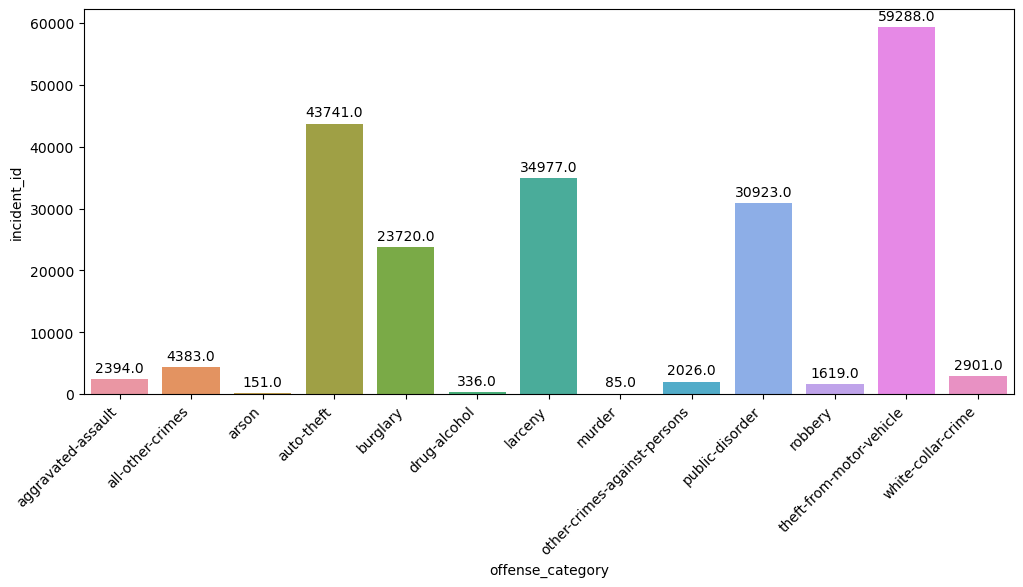

In [168]:
# Create bar chart
ax = sns.barplot(data=grouped, x='offense_category', y='incident_id')

fig = plt.gcf()
fig.set_size_inches(12, 5)

# Add value labels automatically
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
    
# ax.tick_params(axis='x', rotation=45, pad=2)
plt.xticks(rotation=45, ha='right')
plt.show()


In [187]:
# Calculate number of incidents by district by offense category for grouped bar chart
grouped_by_district = df.groupby(['district_id', 'offense_category'])['incident_id'].count().reset_index()
grouped_by_district = grouped_by_district[(grouped_by_district['district_id'] != 'nan')]
grouped_by_district.district_id.unique()
grouped_by_district

,district_id,offense_category,incident_id
0,1,aggravated-assault,345
1,1,all-other-crimes,794
2,1,arson,26
3,1,auto-theft,6281
4,1,burglary,4177
...,...,...,...
100,unknown,larceny,2
101,unknown,other-crimes-against-persons,2
102,unknown,public-disorder,7
103,unknown,robbery,4


In [189]:
grouped_by_district = grouped_by_district.sort_values(
    by=['district_id', 'incident_id'],
    ascending=[True, False]
    )
grouped_by_district

,district_id,offense_category,incident_id
11,1,theft-from-motor-vehicle,9323
3,1,auto-theft,6281
6,1,larceny,5338
9,1,public-disorder,4667
4,1,burglary,4177
...,...,...,...
104,unknown,theft-from-motor-vehicle,4
103,unknown,robbery,4
101,unknown,other-crimes-against-persons,2
100,unknown,larceny,2


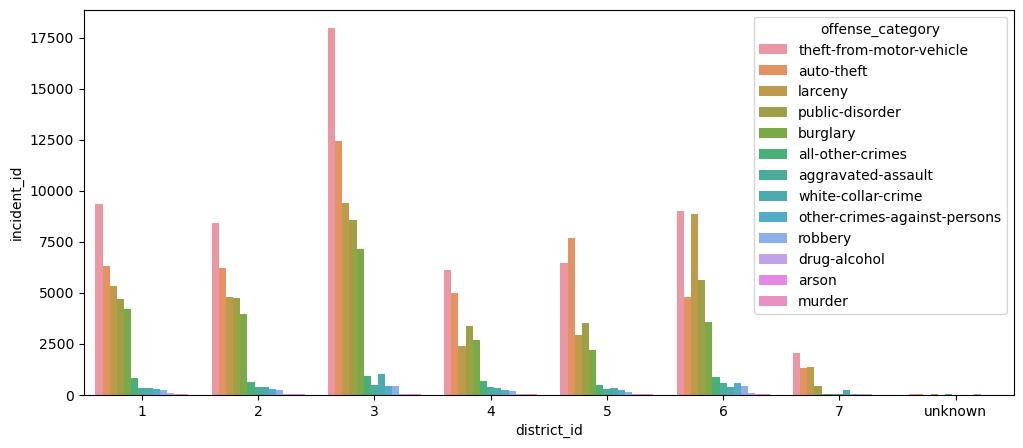

In [190]:
ax = sns.barplot(data=grouped_by_district, x='district_id', y='incident_id', hue='offense_category')
sns.move_legend(ax, 'upper right')

fig = plt.gcf()
fig.set_size_inches(12, 5)

plt.show()